# LABORATORIO 5
### Luis Pedro Gonzalez
20230461


In [16]:
# celda 1

import re
import math
import random
import pandas as pd
import matplotlib.pyplot as plt
import spacy

from collections import Counter
from sklearn.model_selection import train_test_split

random.seed(42)


In [17]:
# celda 2

ruta = 'don-quijote.txt'

with open(ruta, 'r', encoding='utf-8', errors='ignore') as archivo:
    texto = archivo.read()

# quitar el texto adicional de Project Gutenberg
inicio = '*** START OF THIS PROJECT GUTENBERG EBOOK DON QUIJOTE ***'
fin = '*** END OF THIS PROJECT GUTENBERG EBOOK DON QUIJOTE ***'

if inicio in texto:
    texto = texto.split(inicio, 1)[1]

if fin in texto:
    texto = texto.split(fin, 1)[0]

# hacer que el corpus empiece realmente en el libro
titulo = 'El ingenioso hidalgo don Quijote de la Mancha'

if titulo in texto:
    texto = texto[texto.find(titulo):]

# quitar espacios y saltos de línea repetidos
texto = re.sub(r'\s+', ' ', texto).strip()

print("Cantidad de caracteres:", len(texto))
print("Cantidad aproximada de palabras:", len(texto.split()))
print()
print("Inicio del texto:")
print(texto[:500])

Cantidad de caracteres: 2088829
Cantidad aproximada de palabras: 381228

Inicio del texto:
El ingenioso hidalgo don Quijote de la Mancha TASA Yo, Juan Gallo de Andrada, escribano de Cámara del Rey nuestro señor, de los que residen en su Consejo, certifico y doy fe que, habiendo visto por los señores dél un libro intitulado El ingenioso hidalgo de la Mancha, compuesto por Miguel de Cervantes Saavedra, tasaron cada pliego del dicho libro a tres maravedís y medio; el cual tiene ochenta y tres pliegos, que al dicho precio monta el dicho libro docientos y noventa maravedís y medio, en que 


In [18]:
# celda 3

nlp = spacy.blank('es')
nlp.add_pipe('sentencizer')
nlp.max_length = len(texto) + 1000

doc = nlp(texto)

oraciones = []

for oracion in doc.sents:
    
    tokens = []
    
    for token in oracion:
        
        if token.is_space:
            continue
        
        palabra = token.text.lower()
        
        if len(palabra) > 1:
            palabra = palabra.strip('-')
        
        if palabra:
            tokens.append(palabra)
    
    if len(tokens) >= 2:
        tokens = ['<s>'] + tokens + ['</s>']
        oraciones.append(tokens)

print("Cantidad de oraciones:", len(oraciones))
print()

print("Ejemplo de una oración tokenizada:")
print(oraciones[0])

Cantidad de oraciones: 9638

Ejemplo de una oración tokenizada:
['<s>', 'el', 'ingenioso', 'hidalgo', 'don', 'quijote', 'de', 'la', 'mancha', 'tasa', 'yo', ',', 'juan', 'gallo', 'de', 'andrada', ',', 'escribano', 'de', 'cámara', 'del', 'rey', 'nuestro', 'señor', ',', 'de', 'los', 'que', 'residen', 'en', 'su', 'consejo', ',', 'certifico', 'y', 'doy', 'fe', 'que', ',', 'habiendo', 'visto', 'por', 'los', 'señores', 'dél', 'un', 'libro', 'intitulado', 'el', 'ingenioso', 'hidalgo', 'de', 'la', 'mancha', ',', 'compuesto', 'por', 'miguel', 'de', 'cervantes', 'saavedra', ',', 'tasaron', 'cada', 'pliego', 'del', 'dicho', 'libro', 'a', 'tres', 'maravedís', 'y', 'medio', ';', 'el', 'cual', 'tiene', 'ochenta', 'y', 'tres', 'pliegos', ',', 'que', 'al', 'dicho', 'precio', 'monta', 'el', 'dicho', 'libro', 'docientos', 'y', 'noventa', 'maravedís', 'y', 'medio', ',', 'en', 'que', 'se', 'ha', 'de', 'vender', 'en', 'papel', ';', 'y', 'dieron', 'licencia', 'para', 'que', 'a', 'este', 'precio', 'se', 'pued

In [19]:
# celda 4

train, temporal = train_test_split(
    oraciones,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

val, test = train_test_split(
    temporal,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Total de oraciones:", len(oraciones))
print("Entrenamiento:", len(train))
print("Validación:", len(val))
print("Prueba:", len(test))

print()
print("Porcentajes:")
print(f"Train: {len(train) / len(oraciones) * 100:.2f}%")
print(f"Validación: {len(val) / len(oraciones) * 100:.2f}%")
print(f"Prueba: {len(test) / len(oraciones) * 100:.2f}%")

Total de oraciones: 9638
Entrenamiento: 7710
Validación: 964
Prueba: 964

Porcentajes:
Train: 80.00%
Validación: 10.00%
Prueba: 10.00%


In [20]:
# celda 5

palabras_train = [
    palabra
    for oracion in train
    for palabra in oracion
    if palabra not in ['<s>', '</s>']
]

vocab_train = set(palabras_train)

palabras_test = [
    palabra
    for oracion in test
    for palabra in oracion
    if palabra not in ['<s>', '</s>']
]

palabras_oov = [
    palabra for palabra in palabras_test
    if palabra not in vocab_train
]

porcentaje_oov = len(palabras_oov) / len(palabras_test) * 100

print("Tamaño del vocabulario de entrenamiento:", len(vocab_train))
print("Palabras totales en prueba:", len(palabras_test))
print("Palabras OOV en prueba:", len(palabras_oov))
print(f"Porcentaje OOV: {porcentaje_oov:.2f}%")

print()
print("Ejemplos de palabras OOV:")
print(list(dict.fromkeys(palabras_oov))[:20])

Tamaño del vocabulario de entrenamiento: 20730
Palabras totales en prueba: 43298
Palabras OOV en prueba: 1371
Porcentaje OOV: 3.17%

Ejemplos de palabras OOV:
['espantaría', 'retratarle', 'recuerda', 'mejoría', 'amezqueta', 'cumplid', 'nacistes', 'hete', 'roble', 'desgajar', 'afortunado', 'vellas', 'creídas', 'levantándome', 'pagare', 'tráiganme', 'holgáredes', 'desamparando', 'cosió', 'remordiéndole']


# Sección 1: vocabulario, OOV y data sparsity

El vocabulario del conjunto de entrenamiento quedó con 20,730 palabras diferentes. En el conjunto de prueba hubo 43,298 palabras en total y 1,371 de ellas no habían aparecido antes en entrenamiento. Esto representa un 3.17% de palabras OOV.

Aunque el porcentaje no es demasiado alto, sí demuestra el problema de data sparsity. Básicamente, por más grande que sea el texto de entrenamiento, siempre pueden aparecer palabras o combinaciones que el modelo nunca vio. Esto se vuelve todavía más importante cuando pasamos de palabras individuales a bigramas y trigramas, porque hay muchísimas más combinaciones posibles y no todas aparecen suficientes veces en el corpus.

In [21]:
# celda 6

cont_uni = Counter()
cont_bi = Counter()
cont_tri = Counter()

cont_contexto_bi = Counter()
cont_contexto_tri = Counter()

for oracion in train:
    
    # unigramas
    for palabra in oracion[1:]:
        cont_uni[palabra] += 1
    
    # bigramas
    for i in range(1, len(oracion)):
        anterior = oracion[i - 1]
        actual = oracion[i]
        
        cont_bi[(anterior, actual)] += 1
        cont_contexto_bi[anterior] += 1
    
    # trigramas
    for i in range(2, len(oracion)):
        anterior2 = oracion[i - 2]
        anterior1 = oracion[i - 1]
        actual = oracion[i]
        
        cont_tri[(anterior2, anterior1, actual)] += 1
        cont_contexto_tri[(anterior2, anterior1)] += 1

total_uni = sum(cont_uni.values())

# +1 para poder representar <UNK>
vocab_modelo = set(cont_uni.keys())
V = len(vocab_modelo) + 1

print("Unigramas diferentes:", len(cont_uni))
print("Bigramas diferentes:", len(cont_bi))
print("Trigramas diferentes:", len(cont_tri))
print("Tamaño V usado por el modelo:", V)

Unigramas diferentes: 20731
Bigramas diferentes: 124671
Trigramas diferentes: 248328
Tamaño V usado por el modelo: 20732


In [22]:
# celda 7

def ajustar_palabra(palabra):
    if palabra == '<s>':
        return palabra
    
    if palabra in vocab_modelo:
        return palabra
    
    return '<UNK>'


def prob_uni(palabra):
    palabra = ajustar_palabra(palabra)
    return cont_uni[palabra] / total_uni


def prob_bi(anterior, actual):
    anterior = ajustar_palabra(anterior)
    actual = ajustar_palabra(actual)
    
    denominador = cont_contexto_bi[anterior]
    
    if denominador == 0:
        return 0
    
    return cont_bi[(anterior, actual)] / denominador


def prob_tri(anterior2, anterior1, actual):
    anterior2 = ajustar_palabra(anterior2)
    anterior1 = ajustar_palabra(anterior1)
    actual = ajustar_palabra(actual)
    
    denominador = cont_contexto_tri[(anterior2, anterior1)]
    
    if denominador == 0:
        return 0
    
    return cont_tri[(anterior2, anterior1, actual)] / denominador


def prob_oracion(oracion, n):
    prob = 1.0
    
    if n == 1:
        for palabra in oracion[1:]:
            p = prob_uni(palabra)
            
            if p == 0:
                return 0
            
            prob *= p
    
    elif n == 2:
        for i in range(1, len(oracion)):
            p = prob_bi(oracion[i - 1], oracion[i])
            
            if p == 0:
                return 0
            
            prob *= p
    
    elif n == 3:
        # primera palabra usando el inicio de oración
        p = prob_bi(oracion[0], oracion[1])
        
        if p == 0:
            return 0
        
        prob *= p
        
        # resto de la oración usando trigramas
        for i in range(2, len(oracion)):
            p = prob_tri(
                oracion[i - 2],
                oracion[i - 1],
                oracion[i]
            )
            
            if p == 0:
                return 0
            
            prob *= p
    
    return prob


# buscar una oración corta y clara del conjunto de validación
ejemplo_val = None

for oracion in sorted(val, key=len):
    
    if 8 <= len(oracion) <= 14:
        
        contenido = oracion[1:-1]
        
        empieza_bien = contenido[0].isalpha()
        termina_bien = contenido[-1] in ['.', '?', '!']
        suficientes_palabras = sum(
            palabra.isalpha() for palabra in contenido
        ) >= 5
        
        sin_oov = all(
            palabra in vocab_modelo
            for palabra in oracion[1:]
        )
        
        if (
            empieza_bien
            and termina_bien
            and suficientes_palabras
            and sin_oov
            and prob_oracion(oracion, 3) > 0
        ):
            ejemplo_val = oracion
            break


if ejemplo_val is None:
    ejemplo_val = val[0]


print("Oración seleccionada:")
print(" ".join(ejemplo_val[1:-1]))

print()
print(f"Probabilidad unigrama: {prob_oracion(ejemplo_val, 1):.12e}")
print(f"Probabilidad bigrama:  {prob_oracion(ejemplo_val, 2):.12e}")
print(f"Probabilidad trigrama: {prob_oracion(ejemplo_val, 3):.12e}")

Oración seleccionada:
no , por cierto respondió el labrador .

Probabilidad unigrama: 7.386190822436e-21
Probabilidad bigrama:  8.617840102234e-13
Probabilidad trigrama: 9.123849310468e-10


# Sección 2: regla de la cadena y supuesto de Markov

Para la oración seleccionada, el modelo unigrama obtuvo una probabilidad aproximada de 7.39e-21, el bigrama de 8.62e-13 y el trigrama de 9.12e-10. En este ejemplo el trigrama dio la probabilidad más alta, lo cual tiene sentido porque utiliza más información de las palabras anteriores.

El problema de usar directamente la regla de la cadena es que habría que tomar en cuenta todas las palabras anteriores para calcular la probabilidad de cada nueva palabra. En una oración larga eso genera demasiadas combinaciones y muchas probablemente nunca aparecieron en los datos de entrenamiento.

El supuesto de Markov hace este problema mucho más manejable. En lugar de utilizar toda la oración anterior, el bigrama solamente se fija en una palabra previa y el trigrama en las dos anteriores. Se pierde algo de contexto, pero a cambio sí es posible calcular las probabilidades con los datos que tenemos.

In [23]:
# celda 8

def prob_uni_suave(palabra, k):
    palabra = ajustar_palabra(palabra)
    
    return (cont_uni[palabra] + k) / (total_uni + k * V)


def prob_bi_suave(anterior, actual, k):
    anterior = ajustar_palabra(anterior)
    actual = ajustar_palabra(actual)
    
    numerador = cont_bi[(anterior, actual)] + k
    denominador = cont_contexto_bi[anterior] + k * V
    
    return numerador / denominador


def prob_tri_suave(anterior2, anterior1, actual, k):
    anterior2 = ajustar_palabra(anterior2)
    anterior1 = ajustar_palabra(anterior1)
    actual = ajustar_palabra(actual)
    
    numerador = cont_tri[(anterior2, anterior1, actual)] + k
    denominador = cont_contexto_tri[(anterior2, anterior1)] + k * V
    
    return numerador / denominador


def prob_oracion_suave(oracion, n, k):
    prob = 1.0
    
    if n == 1:
        for palabra in oracion[1:]:
            prob *= prob_uni_suave(palabra, k)
    
    elif n == 2:
        for i in range(1, len(oracion)):
            prob *= prob_bi_suave(
                oracion[i - 1],
                oracion[i],
                k
            )
    
    elif n == 3:
        # primera palabra usando bigrama suavizado
        prob *= prob_bi_suave(
            oracion[0],
            oracion[1],
            k
        )
        
        # resto usando trigramas suavizados
        for i in range(2, len(oracion)):
            prob *= prob_tri_suave(
                oracion[i - 2],
                oracion[i - 1],
                oracion[i],
                k
            )
    
    return prob


# buscar una oración con algún bigrama no visto en entrenamiento
ejemplo_suavizado = None

for oracion in sorted(val, key=len):
    
    if 6 <= len(oracion) <= 16:
        
        sin_oov = all(
            palabra in vocab_modelo
            for palabra in oracion[1:]
        )
        
        if sin_oov and prob_oracion(oracion, 2) == 0:
            ejemplo_suavizado = oracion
            break


print("Oración seleccionada:")
print(" ".join(ejemplo_suavizado[1:-1]))

print()
print("Sin suavizado:")
print(f"{prob_oracion(ejemplo_suavizado, 2):.12e}")

print()
print("Laplace (k = 1):")
print(f"{prob_oracion_suave(ejemplo_suavizado, 2, 1):.12e}")

print()
print("Add-k (k = 0.1):")
print(f"{prob_oracion_suave(ejemplo_suavizado, 2, 0.1):.12e}")

print()
print("Add-k (k = 0.01):")
print(f"{prob_oracion_suave(ejemplo_suavizado, 2, 0.01):.12e}")

Oración seleccionada:
¡bendito sea dios !

Sin suavizado:
0.000000000000e+00

Laplace (k = 1):
1.310069643415e-17

Add-k (k = 0.1):
1.211931508947e-14

Add-k (k = 0.01):
9.568574919196e-13


# Sección 3: efecto del suavizado



Con la oración "¡bendito sea dios!", el modelo de bigramas sin suavizado dio una probabilidad de 0. Esto pasó porque al menos uno de los bigramas de esa oración nunca apareció en entrenamiento. Como las probabilidades se multiplican, basta con que una sea cero para que toda la oración termine con probabilidad cero.

Después de aplicar suavizado, la probabilidad dejó de ser cero. Con Laplace, usando k = 1, fue aproximadamente 1.31e-17. Con add-k de 0.1 fue 1.21e-14 y con k = 0.01 fue 9.57e-13.

Lo importante aquí no es que las probabilidades sean grandes, porque siguen siendo bastante pequeñas, sino que el modelo ya no trata una combinación nunca vista como algo completamente imposible. El suavizado toma una pequeña parte de la probabilidad de las combinaciones que sí aparecieron y se la asigna a las que no aparecieron. Esto también ayuda a que el modelo no confíe demasiado en que el conjunto de entrenamiento representa todas las posibilidades que existen.

In [24]:
# celda 9

def perplexidad(datos, n, k):
    
    suma_logs = 0
    cantidad = 0
    
    for oracion in datos:
        
        if n == 1:
            for palabra in oracion[1:]:
                p = prob_uni_suave(palabra, k)
                suma_logs += math.log(p)
                cantidad += 1
        
        elif n == 2:
            for i in range(1, len(oracion)):
                p = prob_bi_suave(
                    oracion[i - 1],
                    oracion[i],
                    k
                )
                
                suma_logs += math.log(p)
                cantidad += 1
        
        elif n == 3:
            # primera palabra usando bigrama suavizado
            p = prob_bi_suave(
                oracion[0],
                oracion[1],
                k
            )
            
            suma_logs += math.log(p)
            cantidad += 1
            
            # resto usando trigramas suavizados
            for i in range(2, len(oracion)):
                p = prob_tri_suave(
                    oracion[i - 2],
                    oracion[i - 1],
                    oracion[i],
                    k
                )
                
                suma_logs += math.log(p)
                cantidad += 1
    
    return math.exp(-suma_logs / cantidad)

In [25]:
# celda 10

k_base = 0.01

ppl_uni = perplexidad(val, 1, k_base)
ppl_bi = perplexidad(val, 2, k_base)
ppl_tri = perplexidad(val, 3, k_base)

tabla_ppl = pd.DataFrame({
    'Modelo': ['Unigrama', 'Bigrama', 'Trigrama'],
    'Perplejidad': [ppl_uni, ppl_bi, ppl_tri]
})

tabla_ppl

,Modelo,Perplejidad
0,Unigrama,621.973306
1,Bigrama,427.039527
2,Trigrama,2326.316467


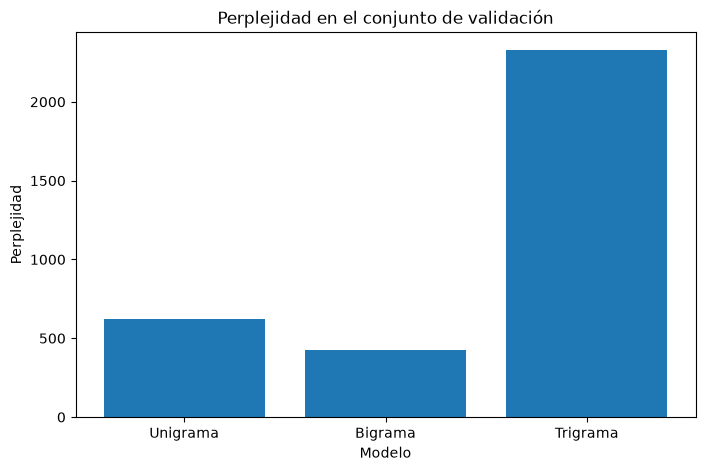

In [26]:
# celda 11

plt.figure(figsize=(8, 5))

plt.bar(
    tabla_ppl['Modelo'],
    tabla_ppl['Perplejidad']
)

plt.xlabel('Modelo')
plt.ylabel('Perplejidad')
plt.title('Perplejidad en el conjunto de validación')

plt.show()

In [27]:
# celda 12

valores_k = [0.01, 0.1, 1]

resultados_k = []

for k in valores_k:
    ppl = perplexidad(val, 2, k)
    resultados_k.append([k, ppl])

tabla_k = pd.DataFrame(
    resultados_k,
    columns=['k', 'Perplejidad bigrama']
)

tabla_k

,k,Perplejidad bigrama
0,0.01,427.039527
1,0.10,688.366926
2,1.00,1799.428249


In [28]:
# celda 13

mejor_fila = tabla_ppl.loc[
    tabla_ppl['Perplejidad'].idxmin()
]

mejor_modelo = mejor_fila['Modelo']

if mejor_modelo == 'Unigrama':
    mejor_n = 1
elif mejor_modelo == 'Bigrama':
    mejor_n = 2
else:
    mejor_n = 3

ppl_test = perplexidad(test, mejor_n, k_base)

print("Mejor modelo según validación:", mejor_modelo)
print(f"Perplejidad en validación: {mejor_fila['Perplejidad']:.4f}")
print(f"Perplejidad final en prueba: {ppl_test:.4f}")

Mejor modelo según validación: Bigrama
Perplejidad en validación: 427.0395
Perplejidad final en prueba: 465.3258


# Sección 4: análisis de perplejidad


Los resultados de validación fueron bastante claros. El unigrama obtuvo una perplejidad de 621.97, el bigrama de 427.04 y el trigrama de 2326.32. Como una perplejidad más baja representa una mejor capacidad para predecir el texto, el bigrama fue el modelo que mejor funcionó.

Al principio se podría pensar que el trigrama debería ser mejor simplemente porque utiliza más contexto, pero los resultados muestran que no siempre funciona así. El unigrama tiene muy poco contexto, mientras que el trigrama tiene el problema contrario. Existen demasiadas combinaciones de tres palabras y muchas aparecen pocas veces. El bigrama quedó en un punto medio, usando contexto sin llegar a sufrir tanto por la falta de datos.

Por esa razón se seleccionó el bigrama como modelo final. En el conjunto de prueba obtuvo una perplejidad de 465.33, que no está demasiado alejada de la perplejidad de validación de 427.04. Esto indica que el modelo mantuvo un comportamiento parecido cuando se probó con información diferente a la utilizada para escogerlo.

También se notó bastante el efecto de cambiar k. Con k = 0.01 la perplejidad fue 427.04, con k = 0.1 aumentó a 688.37 y con k = 1 llegó a 1799.43. En este caso, aumentar demasiado el suavizado terminó perjudicando al modelo, porque se estaba dando demasiada probabilidad a combinaciones poco frecuentes o que nunca habían aparecido. Por eso k = 0.01 terminó funcionando mejor.

In [29]:
# celda 14

# solo usar palabras como posibles sugerencias
candidatos = [
    palabra
    for palabra in vocab_modelo
    if palabra not in ['<s>', '</s>', '<UNK>']
    and any(letra.isalpha() for letra in palabra)
]


def autocompletar(fragmento, n=mejor_n, k=k_base, top=5):
    
    doc_fragmento = nlp.make_doc(fragmento.lower())
    
    tokens = [
        token.text
        for token in doc_fragmento
        if not token.is_space
    ]
    
    resultados = []
    
    for palabra in candidatos:
        
        if n == 1:
            p = prob_uni_suave(palabra, k)
        
        elif n == 2:
            if len(tokens) == 0:
                anterior = '<s>'
            else:
                anterior = tokens[-1]
            
            p = prob_bi_suave(anterior, palabra, k)
        
        else:
            if len(tokens) >= 2:
                anterior2 = tokens[-2]
                anterior1 = tokens[-1]
            
            elif len(tokens) == 1:
                anterior2 = '<s>'
                anterior1 = tokens[-1]
            
            else:
                anterior2 = '<s>'
                anterior1 = '<s>'
            
            p = prob_tri_suave(
                anterior2,
                anterior1,
                palabra,
                k
            )
        
        resultados.append((palabra, p))
    
    resultados.sort(
        key=lambda x: x[1],
        reverse=True
    )
    
    return resultados[:top]

In [30]:
# celda 15

fragmentos = []
contextos_usados = set()

for oracion in test:
    
    if len(fragmentos) == 5:
        break
    
    palabras = oracion[1:-1]
    
    if len(palabras) < 6:
        continue
    
    for pos in range(3, min(8, len(palabras))):
        
        fragmento_tokens = palabras[:pos]
        palabra_real = palabras[pos]
        
        # la palabra real debe ser una palabra y no un signo
        if not palabra_real.isalpha():
            continue
        
        # el fragmento debe terminar en una palabra
        if not fragmento_tokens[-1].isalpha():
            continue
        
        # revisar que el contexto haya aparecido en entrenamiento
        if mejor_n == 1:
            contexto = 'unigrama'
            contexto_valido = True
        
        elif mejor_n == 2:
            contexto = fragmento_tokens[-1]
            
            contexto_valido = cont_contexto_bi[
                ajustar_palabra(contexto)
            ] >= 5
        
        else:
            contexto = (
                fragmento_tokens[-2],
                fragmento_tokens[-1]
            )
            
            contexto_valido = cont_contexto_tri[
                (
                    ajustar_palabra(contexto[0]),
                    ajustar_palabra(contexto[1])
                )
            ] >= 5
        
        if contexto_valido and contexto not in contextos_usados:
            
            fragmento = " ".join(fragmento_tokens)
            
            fragmentos.append(
                (fragmento, palabra_real)
            )
            
            contextos_usados.add(contexto)
            break


for numero, (fragmento, palabra_real) in enumerate(fragmentos, 1):
    
    sugerencias = autocompletar(fragmento)
    
    print(f"Fragmento {numero}: {fragmento}")
    print("Palabra real siguiente:", palabra_real)
    print("Top 5 sugerencias:")
    
    for palabra, prob in sugerencias:
        print(f"  {palabra}: {prob:.6f}")
    
    print()

Fragmento 1: en el espacio
Palabra real siguiente: que
Top 5 sugerencias:
  de: 0.026723
  que: 0.019099
  y: 0.015287
  para: 0.007662
  no: 0.003850

Fragmento 2: viéndole , pues , caído
Palabra real siguiente: en
Top 5 sugerencias:
  en: 0.037492
  ni: 0.004203
  sancho: 0.004203
  o: 0.004203
  por: 0.004203

Fragmento 3: cardenio estaba en
Palabra real siguiente: el
Top 5 sugerencias:
  la: 0.111417
  el: 0.109069
  su: 0.038168
  las: 0.031709
  los: 0.025837

Fragmento 4: pero , en fin , tanto
Palabra real siguiente: hicieron
Top 5 sugerencias:
  que: 0.150871
  como: 0.016990
  bien: 0.016990
  la: 0.015104
  el: 0.015104

Fragmento 5: yo así lo
Palabra real siguiente: creo
Top 5 sugerencias:
  que: 0.416401
  cual: 0.050537
  menos: 0.035714
  es: 0.015837
  mesmo: 0.013816



# Sección 5: análisis del autocompletado

Para el autocompletado se utilizó el bigrama porque fue el modelo con menor perplejidad. Los resultados fueron mixtos, pero en general sí se puede ver que el modelo aprendió varias relaciones entre palabras.

Por ejemplo, en "en el espacio", la palabra real siguiente era "que" y el modelo la colocó como segunda opción. En "cardenio estaba en", la palabra real era "el" y también apareció entre las primeras sugerencias. Son buenos ejemplos de que el modelo sí logra encontrar continuaciones que tienen sentido.

En otros casos no acertó la palabra real. Esto se nota, por ejemplo, en fragmentos como "pero, en fin, tanto" o "yo así lo". Esto tampoco es tan extraño porque el bigrama únicamente toma en cuenta la última palabra del fragmento. Aunque para nosotros toda la frase tiene un significado, el modelo realmente no está entendiendo la oración completa.

También aparecieron palabras como "mesmo", que actualmente no son tan comunes. Esto es esperable porque todo el modelo fue entrenado con Don Quijote. Por lo tanto, las sugerencias reflejan bastante el vocabulario y la forma de escribir de la época en la que fue escrita la novela, en lugar del español que usamos actualmente.